In [2]:
from xtquant import xtdatacenter as xtdc
from xtquant import xtdata  
import pandas as pd 
import random
import datetime
import tushare as ts
import os
import yaml
def load_config():
    with open("config.yaml", "r") as f:
        config = yaml.safe_load(f)
    return config
config = load_config()
TUSHARE_API_KEY = config["api"]["tushare_api_key"]
XTQUANT_API_KEY = config["api"]["xtquant_api_key"]
ts.set_token(TUSHARE_API_KEY)
pro = ts.pro_api(TUSHARE_API_KEY)
# xtdc.set_token("857b1fa0068599ccb191546f86bac28e09d8a727") # 试用过期
xtdc.set_token(XTQUANT_API_KEY)
xtdc.set_data_home_dir("../xtquant_tushare/srv/xuntoudata/data")
xtdc.init(False)
actual_port = random.randint(58600,58700)
xtdc.listen(port=actual_port)
print(f"服务启动,开放端口：{actual_port}")

服务启动,开放端口：58605


In [2]:
index_code = '000852.SH'
# index_code = '000905.SH'
# index_code = '000903.SH'
# index_code = '000901.SH'
# index_code = '000300.SH'
file_dir = ""
for filedir in os.listdir(f'./ref/project_/cal_index_data/'):
    if index_code in filedir:
        file_dir = filedir
        break
# 从已有的cal_weight_df_date.csv中导出权重和收盘价
# 获取上一个交易日的日期
def get_prev_trade_date(date): # 函数从当前日期往回找，直到找到一个交易日
    prev_day =(pd.to_datetime(date) - pd.Timedelta(days=1)).strftime('%Y%m%d')
    while True:
        if int(pro.trade_cal(exchange='SSE', start_date=prev_day, end_date=prev_day)['is_open'][0]) == 1:
            return prev_day
        else :
            prev_day =(pd.to_datetime(prev_day) - pd.Timedelta(days=1)).strftime('%Y%m%d')
def get_closePrice_and_weight_from_csv(index_code,last_trade_day): # 从csv文件中获取上一个交易日的成分股权重和收盘价    
    last_date_info = pd.read_csv(f'./ref/project_/cal_index_data/{file_dir}/cal_weight_df_{index_code}_{last_trade_day}_副本.csv')
    print(f'读取文件cal_weight_df_{index_code}_{last_trade_day}_副本.csv')
    weight_dict = last_date_info.set_index('code')[f'{last_trade_day}weight'].to_dict()
    P_base_dict = last_date_info.set_index('code')[f'{last_trade_day}close'].to_dict()
    print(f"今天是{now_date}，上一个交易日为{last_trade_day}")
    print(f'成分股权重{weight_dict}')
    print(f'成分股收盘价{P_base_dict}')
    return weight_dict, P_base_dict
now_date = pd.Timestamp(datetime.datetime.now()).date().strftime('%Y%m%d')
last_trade_day = get_prev_trade_date(now_date)
weight_dict,P_base_dict = get_closePrice_and_weight_from_csv(index_code,last_trade_day)


读取文件cal_weight_df_000852.SH_20260326_副本.csv
今天是20260327，上一个交易日为20260326
成分股权重{'000012.SZ': 0.0735174430889926, '000019.SZ': 0.0304306584397466, '000028.SZ': 0.0585243143359059, '000029.SZ': 0.0606782187491736, '000030.SZ': 0.0300538376494845, '000035.SZ': 0.1421411769086845, '000048.SZ': 0.0623275496177493, '000049.SZ': 0.0755926207293259, '000058.SZ': 0.0281006028577125, '000059.SZ': 0.0606575957174999, '000061.SZ': 0.0752246368174352, '000065.SZ': 0.0955592368990174, '000089.SZ': 0.0824643844206471, '000099.SZ': 0.110545634513472, '000156.SZ': 0.0797166099845095, '000403.SZ': 0.1022229988222127, '000420.SZ': 0.1093651666705324, '000422.SZ': 0.1725093130149832, '000498.SZ': 0.0420900479057464, '000503.SZ': 0.0735894687085879, '000543.SZ': 0.1179785220794148, '000550.SZ': 0.0430406946765952, '000552.SZ': 0.0711699913095728, '000555.SZ': 0.1060543315766881, '000557.SZ': 0.0495508807094495, '000567.SZ': 0.0362488268350975, '000581.SZ': 0.1168513751909857, '000589.SZ': 0.0671225011845541,

In [3]:
# 目标获取前一个交易日的指数收盘价
def get_index_closePrice(index_code,last_trade_day): # 获取last_trade_day的指数的收盘价
    xtdata.download_history_data(index_code,period='1d',start_time=last_trade_day, end_time='') 
    index_data = xtdata.get_market_data_ex([],[index_code],period='1d')
    I_base = float(index_data[index_code].loc[f'{last_trade_day}']['close'])
    print(f'{index_code}的{last_trade_day}的收盘价为{I_base}')
    return I_base
I_base = get_index_closePrice(index_code,last_trade_day)


***** xtdata连接成功 2026-03-27 09:00:59*****
服务信息: {'tag': 'xtquant', 'version': '1.0'}
服务地址: 127.0.0.1:58633
数据路径: d:\test_AI_project\xtquant_tushare\srv\xuntoudata\data\datadir
设置xtdata.enable_hello = False可隐藏此消息

000852.SH的20260326的收盘价为7639.376


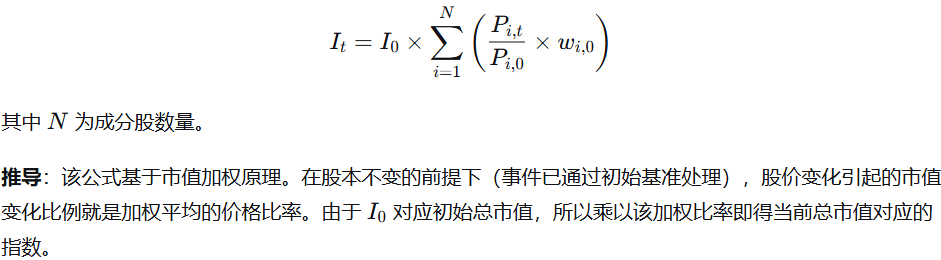

In [ ]:
# 计算实时指数和实时基差
def get_realtime_computing_index(index_code,I_base,P_base_dict,weight_dict,CFE_code,multiple_factor = 200): 
    # 函数参数要注意这个指数和后面的前一天收盘价还有成分股收盘价字典以及权重字典要日期、内容对应。CFE_list是指期货合约代码列表，用来算实时基差
    S_t = 0
    stocks_buy_amount = {}
    code_list = list(weight_dict.keys())
    code_data = xtdata.get_full_tick(code_list)
    real_time_index_data = xtdata.get_full_tick([index_code,CFE_code])
    real_time_index = real_time_index_data[index_code]['lastPrice']
    for code in code_list:
        P_t = code_data[code]['lastPrice']
        P_base = P_base_dict[code]
        W_base = weight_dict[code]
        stocks_buy_amount[code] = int(round((W_base * (multiple_factor * real_time_index) / P_t)/100)) if code_data[code]['stockStatus'] == 3 else int(round((W_base * (multiple_factor * real_time_index) / P_base) /100))
        S_t += W_base * (P_t / P_base) if code_data[code]['stockStatus'] == 3 else W_base 
    I_t = I_base * (S_t / 100)
    print(f'实时推送指数为{real_time_index},计算指数I_t为{I_t},误差为{real_time_index - I_t}，误差率为{(real_time_index - I_t) / real_time_index}')
    print(f"{CFE_code}的当前价格为{real_time_index_data[CFE_code]['lastPrice']}，推送基差为{real_time_index-real_time_index_data[CFE_code]['lastPrice']},计算基差为{I_t-real_time_index_data[CFE_code]['lastPrice']}")
    return I_t-real_time_index_data[CFE_code]['lastPrice'],stocks_buy_amount
CFE_code = 'IM2604.IF'

a,b = get_realtime_computing_index(index_code,I_base,P_base_dict,weight_dict,CFE_code,200)
a

实时推送指数为7697.822,计算指数I_t为7697.526024377565,误差为0.29597562243543507，误差率为3.844926817422318e-05
IM2604.IF的当前价格为7639.400000000001，推送基差为58.42199999999957,计算基差为58.126024377564136


58.126024377564136

### 以下都是草稿

In [47]:
future_data = xtdata.get_instrument_detail("IM2604.IF",iscomplete=True)


In [48]:

print(future_data['OpenInterestMultiple'],future_data['ChargeType'],future_data['ChargeOpen'],future_data['ChargeClose'],future_data['ChargeTodayOpen'],future_data['ChargeTodayClose'])


0 2 0.23 0.23 -1.0 2.3


In [52]:
current_time = datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')
current_time

'2026-03-27 15:45:18'

In [ ]:
# import datetime
# # stock_code = 'IM2603.IF'
# # stock_code = '512100.SH'
# stock_code = '688226.SH'
# # stock_code = ['688226.SH','000009.SZ']
# last_price = None
# def on_data(datas):
#     # get_realtime_computing_index(index_code,I_base,P_base_dict,weight_dict,CFE_list)
#     for stock_code in datas:
#         print(stock_code,datas[stock_code])
#         print(stock_code,datas[stock_code][0]['askVol'],datas[stock_code][0]['bidVol'])        
      
# subscribe_id = xtdata.subscribe_quote(stock_code, period='tick', start_time='', end_time='', count=0, callback=on_data)
# # print(last_price)

In [ ]:
# 取消订阅
# xtdata.unsubscribe_quote(subscribe_id)